# M4b: Real CNN on CIFAR-10 with the TorchAdapter

**Phase 3, second TorchAdapter example.** We step up from the tiny MNIST (28×28
grayscale digits) to CIFAR-10 — 32×32 **color** images in ten classes. Same
six-stage pipeline, same adapters, but a deeper CNN to handle the extra channel
and richer features.

The only difference from M4a (besides the dataset) is the **network**:
a three-block convolutional stack with max-pooling and dropout on the fully
connected head.

**Full data path demonstrated:**
`ImageFolderDataSource → TransformedDataStream → TorchModel → TorchLoss → TorchOptimizer → BasePipeline.run("train")`

**Target:** > 70% test accuracy in about five minutes.

In [ ]:
# Notebooks are examples, not core: imports live at top level here.
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms as T

# The pipeline operates on protocols; the torch adapters satisfy them.
from pipeline.config import Config
from pipeline.data.image_folder import ImageFolderDataSource
from pipeline.data.transforms import TransformedDataStream
from pipeline.evaluation.metrics import Metrics, accuracy
from pipeline.pipeline import BasePipeline, PipelineState
from pipeline.adapters.torch_adapter import TorchLoss, TorchModel, TorchOptimizer
from pipeline.protocols import Batch
from pipeline.utils.seed import set_seed

# Use a GPU when one is available, else CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print("Pipeline components: TorchModel, TorchLoss, TorchOptimizer")

In [2]:
# Download CIFAR-10 and write PNGs on disk into an ImageFolder structure:
# train/0/, train/1/, ... and val/0/, val/1/, ...
#
# ImageFolderDataSource reads one subfolder per class and assigns integer labels
# in alphabetical order, so the folder names are zero-padded ("00", not "0") so
# the class order matches the canonical CIFAR label order.

# Raw CIFAR-10 is cached to a stable path (~/.local/share) so it is downloaded
# only once and reused across notebook executions (NOT tmp — it is ~170 MB).
CIFAR_CACHE = Path.home() / ".cache" / "torchvision"
CIFAR_CACHE.mkdir(parents=True, exist_ok=True)

# The written ImageFolder structure goes in a scratch dir (per-execution).
DATA_DIR = Path(tempfile.mkdtemp(prefix="cifar10_pipeline_"))
TRAIN_ROOT = DATA_DIR / "train"    # ImageFolder train root
VAL_ROOT = DATA_DIR / "val"        # ImageFolder validation root


def write_cifar10_to_folders(split: str, dest: Path) -> None:
    """Download one CIFAR-10 split and write it as class subfolders of PNGs."""
    ds = torchvision.datasets.CIFAR10(
        root=str(CIFAR_CACHE), train=(split == "train"), download=True
    )
    # Per-class file counter (avoids re-listing the folder for every image).
    counts: dict[int, int] = {}
    for img, label in ds:
        folder = dest / f"{label:02d}"
        folder.mkdir(parents=True, exist_ok=True)
        i = counts.get(label, 0)
        img.save(folder / f"{i:05d}.png")
        counts[label] = i + 1


print("Writing train images...")
write_cifar10_to_folders("train", TRAIN_ROOT)
print("Writing validation images...")
write_cifar10_to_folders("test", VAL_ROOT)

train_n = sum(len(list(p.glob("*.png"))) for p in TRAIN_ROOT.iterdir())
val_n = sum(len(list(p.glob("*.png"))) for p in VAL_ROOT.iterdir())
print(f"Train images: {train_n}   Val images: {val_n}")
print(f"Class folders: {sorted(p.name for p in TRAIN_ROOT.iterdir())}")

Writing train images...


Writing validation images...


Train images: 50000   Val images: 10000
Class folders: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']


In [ ]:
# A deeper CNN for CIFAR-10. Images are 32x32 RGB (3 channels).
#
# Each conv keeps spatial size (padding=1, same shape) and MaxPool2d(2)
# halves it, so after three blocks the feature map is 4x4:
#   32 -> 16 -> 8 -> 4
# giving a flattened vector of 4 * 4 * 128 = 2048.
n_features = 4 * 4 * 128


class CIFAR10CNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32 -> 32
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 32 -> 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 16 -> 16
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 16 -> 8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 8 -> 8
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 8 -> 4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10),                 # 10 image classes
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))

In [ ]:
# The pipeline stage implementations. This is the same Template Method as M1/M3;
# only the adapters differ.
class CIFAR10Pipeline(BasePipeline):
    def __init__(self, config: Config) -> None:
        super().__init__(config)
        # torchvision transform: PIL image -> (3, 32, 32) float tensor, then
        # normalize each RGB channel to zero mean / unit variance using the
        # dataset-wide CIFAR-10 statistics.
        self.to_tensor = T.Compose(
            [
                T.ToTensor(),
                T.Normalize(
                    mean=(0.4914, 0.4822, 0.4465),
                    std=(0.2470, 0.2435, 0.2616),
                ),
            ]
        )

    def _foldered_stream(self, root: Path) -> TransformedDataStream:
        """ImageFolderDataSource -> TransformedDataStream (PIL list -> tensor)."""
        source = ImageFolderDataSource(
            root, batch_size=self.config.batch_size, shuffle=True, seed=self.config.seed
        )

        def to_tensor_batch(batch: Batch) -> Batch:
            # Stack a batch of PIL Images into one (batch, 3, 32, 32) tensor.
            x = torch.stack([self.to_tensor(img) for img in batch.inputs])
            return Batch(
                inputs=x.to(DEVICE),
                targets=torch.as_tensor(batch.targets).to(DEVICE),
            )

        return TransformedDataStream(source, to_tensor_batch)

    def load_data(self, state: PipelineState) -> None:
        state.data_stream = self._foldered_stream(TRAIN_ROOT)
        state.val_data_stream = self._foldered_stream(VAL_ROOT)

    def build_model(self, state: PipelineState) -> None:
        # Seed BEFORE constructing the module so weight initialization is
        # reproducible across runs. Building the model HERE -- inside the stage,
        # not as a module-level global -- keeps each run self-contained and routes
        # the model through the state bus.
        set_seed(self.config.seed, deterministic=True)
        state.model = TorchModel(CIFAR10CNN().to(DEVICE))
        print(f"CNN parameters: {sum(p.numel() for p in state.model._module.parameters()):,}")
        # Tensor inputs keep the autograd graph intact, so TorchLoss does NOT need
        # a model= for rebinding (that is only needed for detached numpy input).
        state.loss_fn = TorchLoss("CrossEntropyLoss")
        state.optimizer = TorchOptimizer(
            state.model.parameters(), "Adam", lr=self.config.learning_rate
        )
        state.metrics = Metrics(accuracy=accuracy)

    def evaluate(self, state: PipelineState) -> None:
        state.model.eval_mode()
        preds, trues = [], []
        with torch.no_grad():
            for batch in state.val_data_stream:
                logits = state.model.forward(batch.inputs)
                preds.extend(torch.argmax(logits, dim=1).tolist())
                trues.extend(batch.targets.tolist())
        state.metrics.compute(np.array(trues), np.array(preds))

    def export(self, state: PipelineState) -> None:
        # In a real system we would write checkpoints + predictions to disk. For
        # this teaching notebook, just mark the state bus so the stage runs.
        state.predictions = np.array([0])

In [5]:
# Same Config as every other example; nothing torch-specific here.
config = Config(
    batch_size=128,
    num_epochs=10,
    learning_rate=0.001,
    seed=42,
    task_name="m4b-cifar10-cnn",
    output_dir=str(DATA_DIR / "output"),
)

pipeline = CIFAR10Pipeline(config)
print(
    "Config batch_size:",
    config.batch_size,
    "| epochs:",
    config.num_epochs,
    "| lr:",
    config.learning_rate,
)

Config batch_size: 128 | epochs: 10 | lr: 0.001


In [6]:
# Run the full six-stage pipeline. run("train") does:
#   load_data -> extract_features (no-op) -> build_model -> train -> evaluate -> export
import time

from pipeline.hooks.progress import ProgressHook

pipeline.add_hook(ProgressHook())

start = time.time()
state = pipeline.run("train")
elapsed = time.time() - start

acc = state.metrics["accuracy"]

print(f"\nTraining time:        {elapsed:.1f}s")
print(f"Validation accuracy:  {acc:.4f}  ({acc * 100:.1f}%)")
print(f"Final training loss:  {state.history['loss'][-1]:.4f}")

Epoch 1:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 1:   0%|          | 1/391 [00:01<10:16,  1.58s/it]

Epoch 1:   0%|          | 1/391 [00:01<10:16,  1.58s/it, loss=2.3050]

Epoch 1:   1%|          | 2/391 [00:01<10:15,  1.58s/it, loss=2.3133]

Epoch 1:   1%|          | 3/391 [00:01<10:13,  1.58s/it, loss=2.2927]

...

Epoch 10: 100%|█████████▉| 390/391 [00:07<00:00, 49.54it/s, loss=0.3593]

Epoch 10: 100%|█████████▉| 390/391 [00:07<00:00, 49.54it/s, loss=0.5472]

Epoch 10: 100%|██████████| 391/391 [00:07<00:00, 49.54it/s, loss=0.5407]

Epoch 10: 100%|██████████| 391/391 [00:07<00:00, 50.12it/s, loss=0.5407]


Training time:        80.5s
Validation accuracy:  0.7619  (76.2%)
Final training loss:  0.5407


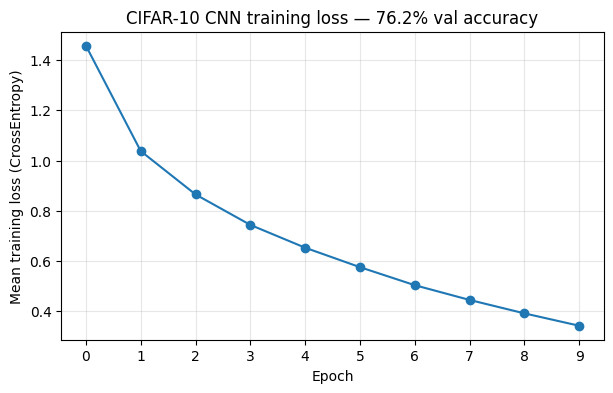

In [7]:
# The training history holds one loss value per batch. Smooth it per-epoch and plot.
losses = state.history["loss"]
num_epochs = config.num_epochs
batches_per_epoch = len(losses) // num_epochs
epoch_losses = [
    np.mean(losses[e * batches_per_epoch : (e + 1) * batches_per_epoch])
    for e in range(num_epochs)
]

plt.figure(figsize=(7, 4))
plt.plot(epoch_losses, marker="o")
plt.xticks(range(num_epochs))
plt.xlabel("Epoch")
plt.ylabel("Mean training loss (CrossEntropy)")
plt.title(f"CIFAR-10 CNN training loss — {acc * 100:.1f}% val accuracy")
plt.grid(True, alpha=0.3)
plt.show()

## Wrap-up

That is the same pipeline from M1/M3/M4a operating on real color images. Nothing in
`BasePipeline` knew about CNNs, convolutions, color channels, or PyTorch — the
**protocols and adapters** carried all of it:

| Component | This example | Why it works |
|---|---|---|
| `ImageFolderDataSource` | reads `train/00/…` folders | DataStream: yields PIL `Batch` |
| `TransformedDataStream` | `ToTensor + Normalize` per batch | decorator maps Batch → Batch |
| `TorchModel` | wraps `CIFAR10CNN` | `forward / parameters / train_mode / eval_mode` |
| `TorchLoss` | `CrossEntropyLoss` | wraps `Loss` with a `backward()` |
| `TorchOptimizer` | `Adam` | drives gradient updates in-place |
| `BasePipeline` | `run("train")` | six-stage Template Method |

**Going deeper than MNIST.** CIFAR-10 is color (3 channels) and far more varied than
digits, so the CNN gained a third convolutional block (32 → 64 → 128) and dropout on
the head. Because each conv uses `padding=1`, only the `MaxPool2d(2)` layers shrink
the map — 32 → 16 → 8 → 4 — yielding a `4 * 4 * 128 = 2048` feature vector before the
fully connected layers.

**Key autograd note:** as in M4a, torch *tensor* input keeps the autograd graph intact,
so `TorchLoss` needs **no** `model=` rebinding. That parameter is only required on the
CSV/numpy path where `TorchModel.forward` returns a detached numpy array and the graph
would otherwise be severed.

To go further: add data augmentation (`RandomCrop`, `RandomHorizontalFlip`) in
`to_tensor_batch` — on CIFAR-10 this is the standard way to push well past 70% —
raise `num_epochs`, or fine-tune the optimizer (e.g. `SGD` with momentum).